In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from pydantic import SecretStr,BaseModel , Field 
from typing import TypedDict,NotRequired,Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
import operator
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver 
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langgraph.prebuilt import ToolNode , tools_condition
from langchain_community.tools.ddg_search import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests

from dotenv import load_dotenv

load_dotenv()

subgraph_llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

parent_llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

C:\Users\welcome\AppData\Local\Temp\ipykernel_7472\16086051.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.ddg_search import DuckDuckGoSearchRun


In [2]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [3]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).text

    return {'answer_hin': translated_text}

In [4]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [5]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").text
    return {'answer_eng': answer}

In [6]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

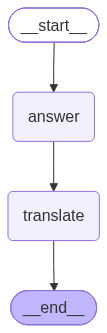

In [7]:
graph = parent_builder.compile()

graph

In [8]:
graph.invoke({'question': 'What is quantum physics'})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also known as quantum mechanics) is the branch of science that studies the behavior of matter and energy at the most fundamental level—the scale of atoms and subatomic particles (like electrons, protons, and photons). \n\nIn our everyday world, things follow the laws of "classical physics" (discovered by Isaac Newton). If you throw a ball, you can predict exactly where it will land. But at the atomic scale, those rules break down completely. Particles behave in strange, counterintuitive, and almost magical ways.\n\nHere are the four key concepts that define quantum physics, explained simply:\n\n### 1. Superposition (Being in two states at once)\nIn classical physics, an object is always in one place at one time. In the quantum world, particles can exist in multiple states or locations at the exact same time. \n* **The Analogy:** Think of a spinning coin. While it is spinning on a table, it isn\'t "heads" or "t